In [1]:
# %cd ..

In [2]:
from src.modeling import load_tsla, train_test_split
series = load_tsla()
train, test = train_test_split(series)
 

Text(0.5, 1.0, 'Train/Test Split')

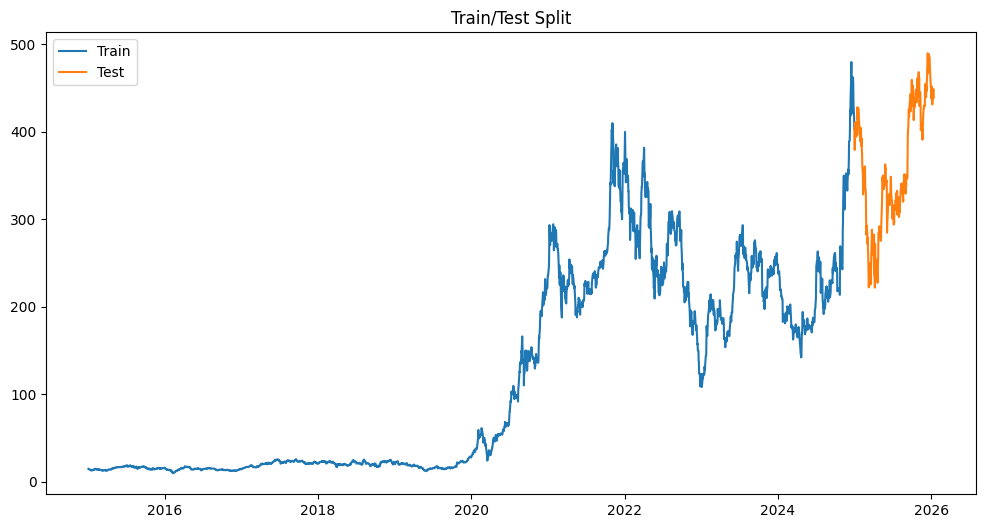

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.legend()
plt.title("Train/Test Split")


In [4]:
from src.modeling import run_arima, evaluate

forecast, order = run_arima(train, test)

mae, rmse, mape = evaluate(test, forecast)

print(order, mae, rmse, mape)

(3, 1, 2) 69.43344593871753 83.22366723622294 22.53569100473884


Text(0.5, 1.0, 'ARIMA Forecast')

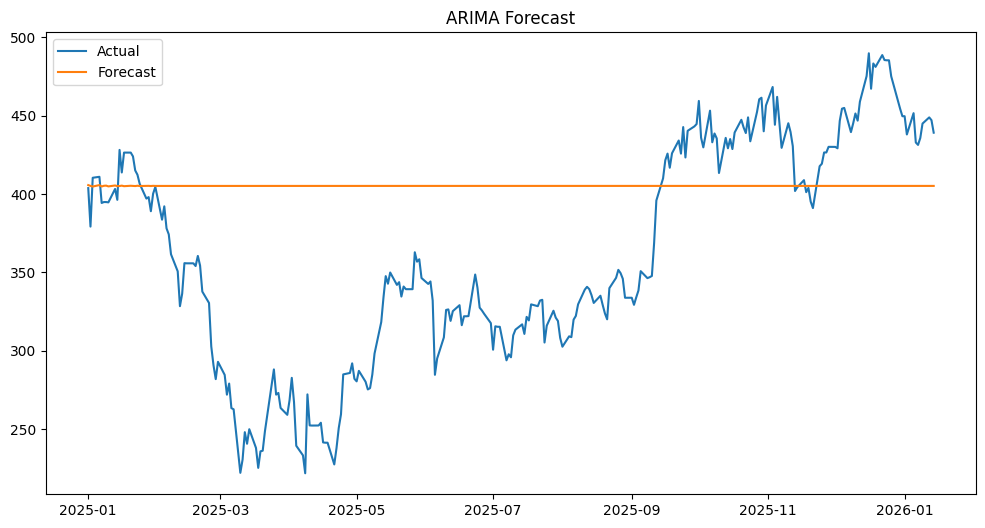

In [5]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")


In [6]:
from src.modeling import run_lstm
y_true, y_pred = run_lstm(series)

c:\Users\assef\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0210
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 9.4473e-04
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 7.9862e-04
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.0646e-04
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 6.5091e-04
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.7094e-04
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 5.6578e-04
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.9236e-04
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.1361e-04
Epoch 10/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 4.2932e-04
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [8]:
# ==========================================
# CALCULATE TSLA FORECAST ANNUAL RETURN
# ==========================================

# 👉 CHANGE THESE VARIABLE NAMES IF NEEDED
# ----------------------------------------
# Option A: If you forecasted PRICES
forecast_prices = forecast        # <-- change to your forecast variable
actual_prices = series

# Option B: If you forecasted RETURNS instead
forecast_returns = None           # put your returns forecast variable here if used

# Forecast horizon in DAYS
forecast_days = 180    # change if your forecast is different


# ==========================================
# METHOD 1 — PRICE FORECAST
# ==========================================
if forecast_prices is not None:
    start_price = actual_prices.iloc[-1]
    end_price = forecast_prices.iloc[-1]

    forecast_return = (end_price - start_price) / start_price
    tsla_forecast_annual = forecast_return * (252 / forecast_days)

    print("Start Price:", start_price)
    print("End Forecast Price:", end_price)
    print("Forecast Return:", forecast_return)
    print("Annualized TSLA Forecast:", tsla_forecast_annual)


# ==========================================
# METHOD 2 — RETURN FORECAST
# ==========================================
if forecast_returns is not None:
    tsla_forecast_annual = forecast_returns.mean() * 252
    print("Annualized TSLA Forecast:", tsla_forecast_annual)


Start Price: 439.2000122070313
End Forecast Price: 405.24137359164365
Forecast Return: -0.07731930253084815
Annualized TSLA Forecast: -0.10824702354318741


In [ ]:
# Example values – replace with YOUR actual results
arima_mae = 69.4334459
arima_rmse = 83.223667
arima_mape = 22.535691

lstm_mae = lstm_mae
lstm_rmse = lstm_rmse
lstm_mape = lstm_mape
